In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    root = Path(__file__).resolve().parents[1]
except NameError:
    root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()

inp = root / "data" / "norw010-rwl-noaa.txt"
outdir = root / "results" / "python"

# keep_series = None
# drop_series = None
drop_series = [
        "ff201a",
        "ff201b",
        "ff202a",
        "ff202b",
        "ff203a",
        "ff203b",
        "ff204a",
        "ff204b",
        "ff205a",
        "ff205b",
        "ff207a",
        "ff207b",
        "ff208a",
        "ff208b",
        "ff209a",
        "ff209b",
        "ff210a",
        "ff210b",
        "ff211a",
        "ff211b",
        "ff213a",
        "ff213b",
        "ff216a",
        "ff216b",
        "ff217a",
        "ff217b",
        "ff218a",
        "ff218b",
        "ff220a",
        "ff220b",
        "ff221a",
        "ff221b",
        "ff222a",
        "ff222b",
        "ff224a",
        "ff224b",
        "ff225a",
        "ff225b",
        "ff228a",
        "ff228b",
        "ff229a",
        "ff229b",
        "ff252a",
        "ff252b",
        "ff253a",
        "ff253c",
        "ff254a",
        "ff254b",
        "ff255a",
        "ff255b",
        "ff256a",
        "ff256b",
        "ff257b",
        "ff257c",
        "ff260b",
        "ff260c"
]

smooth_window = 51
special_to_nan = [0.0, 0.001, 0.005, 0.010]

pad = smooth_window // 2

x = pd.read_csv(inp, sep="\t", comment="#", na_values="NA").rename(columns={"age_CE": "year"})
x.columns = ["year"] + [c[:-4] if c.endswith("_raw") else c for c in x.columns[1:]]
x = x.set_index("year").apply(pd.to_numeric, errors="coerce")

# if keep_series:
#     missing = sorted(set(keep_series) - set(x.columns))
#     if missing:
#         raise ValueError(f"missing series: {missing}")
#     x = x.loc[:, list(keep_series)]

if drop_series:
    missing = sorted(set(drop_series) - set(x.columns))
    if missing:
        raise ValueError(f"missing drop_series: {missing}")
    x = x.drop(columns=list(drop_series))

input_na = int(x.isna().sum().sum())

special_counts = {}
for v in special_to_nan:
    mask = np.isclose(x, v, rtol=0, atol=1e-12)
    special_counts[v] = int(mask.sum().sum())
    x = x.mask(mask, np.nan)

keep_year = x.notna().any(axis=1)
dropped_all_nan_years = int((~keep_year).sum())
x = x.loc[keep_year]

spans = {}
for c in x.columns:
    s = x[c]
    if s.notna().any():
        spans[c] = (s.first_valid_index(), s.last_valid_index())

m = max(int(b - a + 1) for a, b in spans.values())
a = np.full((m, len(spans)), np.nan)

for j, c in enumerate(spans):
    y0, y1 = spans[c]
    v = x.loc[y0:y1, c].to_numpy(float)
    a[:len(v), j] = v

n_age = np.sum(~np.isnan(a), axis=1)
g_raw = np.nanmean(a, axis=1)
g_raw = pd.Series(g_raw).interpolate(limit_direction="both").to_numpy()

g_pad = np.pad(g_raw, pad_width=pad, mode="reflect")
g = (
    pd.Series(g_pad)
    .rolling(smooth_window, center=True, min_periods=1)
    .mean()
    .to_numpy()[pad:-pad]
)

y = pd.DataFrame(index=x.index, columns=x.columns, dtype=float)

for c, (y0, y1) in spans.items():
    v = x.loc[y0:y1, c].to_numpy(float)
    y.loc[y0:y1, c] = v / g[:len(v)]

y.insert(0, "year", y.index.astype(int))

n_series_out = len(spans)
out = outdir / f"tree_rwi_python_{n_series_out}.csv"

out.parent.mkdir(parents=True, exist_ok=True)
y.to_csv(out, index=False)


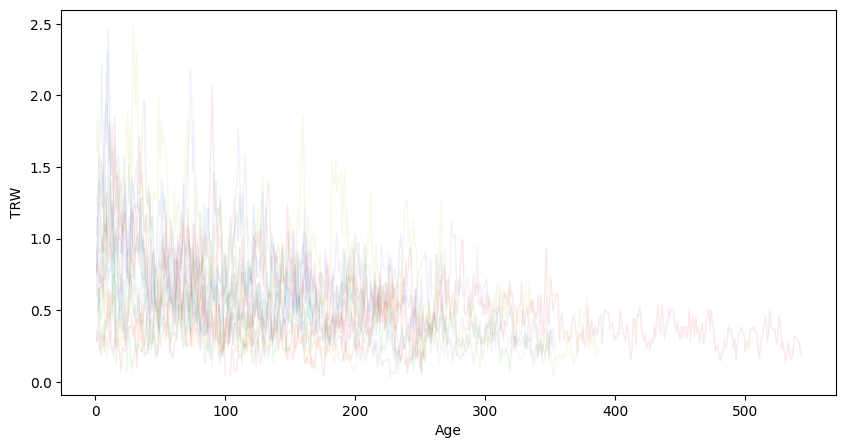

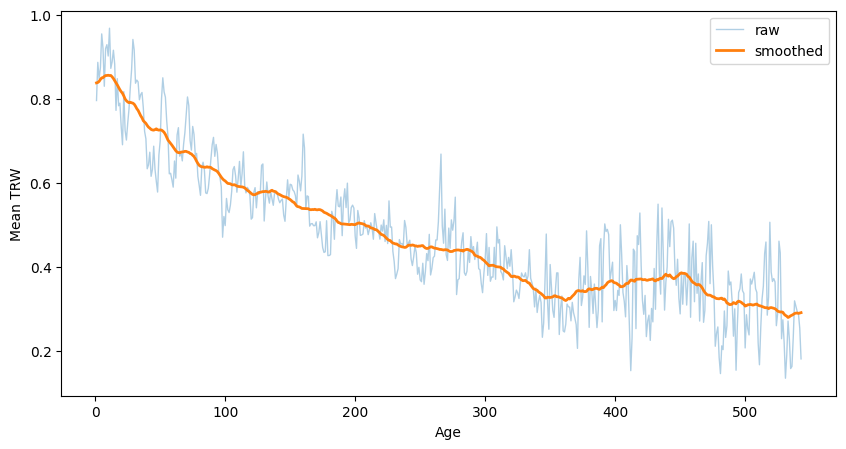

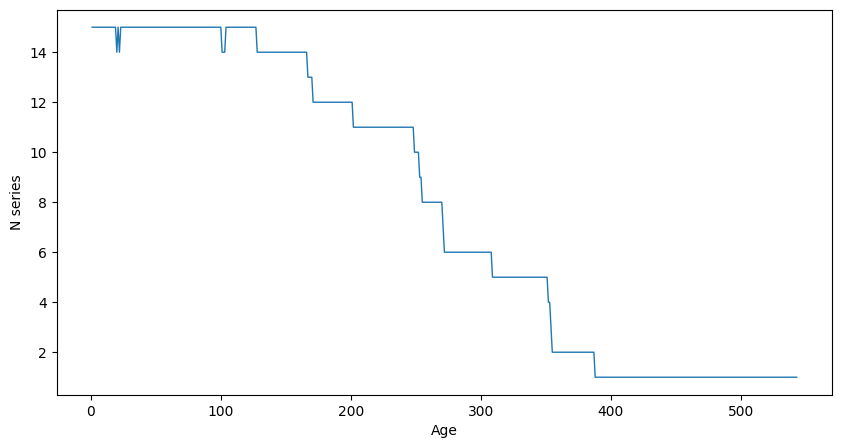

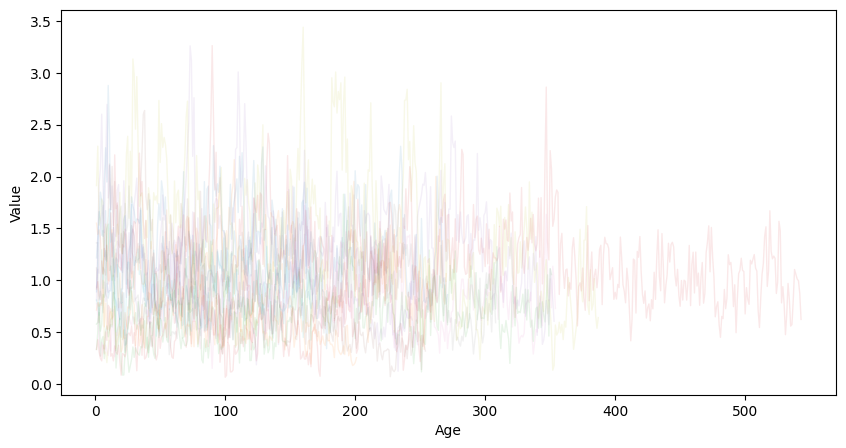

In [2]:
y_tree = y.drop(columns="year")

b = np.full((max(y_tree[c].notna().sum() for c in y_tree.columns), y_tree.shape[1]), np.nan)
for j, c in enumerate(y_tree.columns):
    v = y_tree[c].dropna().to_numpy(float)
    b[:len(v), j] = v

age_raw = np.arange(1, a.shape[0] + 1)
age_norm = np.arange(1, b.shape[0] + 1)

plt.figure(figsize=(10, 5))
for j in range(a.shape[1]):
    plt.plot(age_raw, a[:, j], alpha=0.10, lw=1)
plt.xlabel("Age")
plt.ylabel("TRW")
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(g_raw) + 1), g_raw, alpha=0.35, lw=1, label="raw")
plt.plot(np.arange(1, len(g) + 1), g, lw=2, label="smoothed")
plt.xlabel("Age")
plt.ylabel("Mean TRW")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(n_age) + 1), n_age, lw=1)
plt.xlabel("Age")
plt.ylabel("N series")
plt.show()

plt.figure(figsize=(10, 5))
for j in range(b.shape[1]):
    plt.plot(age_norm, b[:, j], alpha=0.10, lw=1)
plt.xlabel("Age")
plt.ylabel("Value")
plt.show()